# EMA Affect Modelling — Proof of Concept

Model **EM_PA**, **EM_NA** (bounded [0, 1]) and **EM_BO** (binary 0/1) from ecological momentary
assessment data using the vaelong VAE framework.

**Features:**
- EM_PA, EM_NA: bounded outcome variables
- EM_BO: binary outcome variable
- sin_hrs, cos_hrs: continuous time-varying features
- AGE, SEX_1, SEX_2, SEX_3: baseline covariates

**Models:**
- Dense VAE with EM imputation + hyperparameter tuning
- Linear Mixed Model (LMM) benchmark for continuous/bounded outcomes
- Generalised Linear Mixed Model (GLMM, logistic) for binary outcome

**Evaluation:**
- Train (60%) / Validation (20%) / Test (20%) split
- Validation set used for HP tuning and early stopping
- Test set used for final metric reporting (no information leak)

In [1]:
import warnings
import itertools
import copy

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, log_loss
from torch.utils.data import DataLoader

from vaelong import (
    VariableConfig, VariableSpec,
    LongitudinalVAE,
    VAETrainer, LongitudinalDataset,
    create_missing_mask,
)

torch.manual_seed(42)
np.random.seed(42)

## 1. Load and reshape data

In [2]:
df = pd.read_parquet("W:/parquetdata/Final_DF.parquet")
df = df.sort_values(["id", "hrs_since_start"]).reset_index(drop=True)

subject_ids = sorted(df["id"].unique())
n_subjects = len(subject_ids)
seq_len = 105

outcome_cols = ["EM_PA", "EM_NA", "EM_BO"]
time_cols = ["sin_hrs", "cos_hrs"]
feature_cols = outcome_cols + time_cols
n_features = len(feature_cols)

baseline_cols = ["AGE", "SEX_1", "SEX_2", "SEX_3"]
n_baseline = len(baseline_cols)

print(f"Subjects: {n_subjects}, Sequence length: {seq_len}")
print(f"Features: {feature_cols}")
print(f"Baseline: {baseline_cols}")

Subjects: 1174, Sequence length: 105
Features: ['EM_PA', 'EM_NA', 'EM_BO', 'sin_hrs', 'cos_hrs']
Baseline: ['AGE', 'SEX_1', 'SEX_2', 'SEX_3']


## 2. Build 3D arrays

In [3]:
data = np.zeros((n_subjects, seq_len, n_features), dtype=np.float32)
mask = np.ones((n_subjects, seq_len, n_features), dtype=np.float32)
baseline = np.zeros((n_subjects, n_baseline), dtype=np.float32)

id_to_idx = {sid: i for i, sid in enumerate(subject_ids)}

for sid, grp in df.groupby("id"):
    i = id_to_idx[sid]
    grp = grp.sort_values("hrs_since_start").reset_index(drop=True)

    for j, col in enumerate(feature_cols):
        vals = grp[col].values
        data[i, :, j] = np.nan_to_num(vals, nan=0.0)
        mask[i, :, j] = (~np.isnan(vals)).astype(np.float32)

    baseline[i] = grp[baseline_cols].iloc[0].values

# sin_hrs, cos_hrs are always observed
for j, col in enumerate(feature_cols):
    if col in time_cols:
        mask[:, :, j] = 1.0

observed_rate = mask[:, :, :len(outcome_cols)].mean()
print(f"Observed rate (outcomes): {observed_rate:.1%}")
print(f"Data shape:     {data.shape}")
print(f"Baseline shape: {baseline.shape}")

Observed rate (outcomes): 39.3%
Data shape:     (1174, 105, 5)
Baseline shape: (1174, 4)


## 3. Variable configuration and dataset

In [4]:
var_config = VariableConfig(variables=[
    VariableSpec(name="EM_PA",    var_type="bounded", lower=0.0, upper=1.0),
    VariableSpec(name="EM_NA",    var_type="bounded", lower=0.0, upper=1.0),
    VariableSpec(name="EM_BO",    var_type="binary"),
    VariableSpec(name="sin_hrs",  var_type="continuous"),
    VariableSpec(name="cos_hrs",  var_type="continuous"),
])

dataset = LongitudinalDataset(
    data, mask=mask, var_config=var_config,
    baseline_covariates=baseline, normalize=True,
)

train_size = int(0.6 * n_subjects)
val_size = int(0.2 * n_subjects)
test_size = n_subjects - train_size - val_size
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size],
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Train: {train_size}, Validation: {val_size}, Test: {test_size}")
print(f"Bounded indices: {var_config.bounded_indices}")
print(f"Binary indices:  {var_config.binary_indices}")

Train: 704, Validation: 234, Test: 236
Bounded indices: [0, 1]
Binary indices:  [2]


## 4. Hyperparameter tuning

In [5]:
hp_grid = {
    "learning_rate": [1e-4, 5e-4, 1e-3],
    "weight_decay": [0.0, 1e-4, 1e-3],
}

hp_combos = list(itertools.product(hp_grid["learning_rate"], hp_grid["weight_decay"]))
print(f"Tuning over {len(hp_combos)} hyperparameter combinations...\n")

best_val_loss = float("inf")
best_hp = None
tuning_results = []

for lr, wd in hp_combos:
    torch.manual_seed(42)
    np.random.seed(42)

    m = LongitudinalVAE(
        input_dim=var_config.n_features,
        hidden_dim=64,
        latent_dim=16,
        seq_len=seq_len,
        n_baseline=n_baseline,
        var_config=var_config,
    )
    t = VAETrainer(m, learning_rate=lr, beta=0.5, var_config=var_config,
                   weight_decay=wd)

    h = t.fit(
        train_loader, val_loader=val_loader, epochs=200, verbose=False,
        use_em_imputation=True, em_iterations=2, patience=20,
    )

    final_val = min(h["val_loss"])
    tuning_results.append({"lr": lr, "weight_decay": wd, "best_val_loss": final_val})
    print(f"  lr={lr:.0e}, wd={wd:.0e}  ->  best val loss = {final_val:.4f}")

    if final_val < best_val_loss:
        best_val_loss = final_val
        best_hp = {"learning_rate": lr, "weight_decay": wd}

tuning_df = pd.DataFrame(tuning_results)
print(f"\nBest: lr={best_hp['learning_rate']:.0e}, "
      f"weight_decay={best_hp['weight_decay']:.0e} "
      f"(val loss = {best_val_loss:.4f})")

Tuning over 9 hyperparameter combinations...

  lr=1e-04, wd=0e+00  ->  best val loss = 2109.1525
  lr=1e-04, wd=1e-04  ->  best val loss = 2108.7564
  lr=1e-04, wd=1e-03  ->  best val loss = 2108.3754
  lr=5e-04, wd=0e+00  ->  best val loss = -1029.0931
  lr=5e-04, wd=1e-04  ->  best val loss = -1037.1209
  lr=5e-04, wd=1e-03  ->  best val loss = -996.6476
  lr=1e-03, wd=0e+00  ->  best val loss = -1019.1149
  lr=1e-03, wd=1e-04  ->  best val loss = -1024.2961
  lr=1e-03, wd=1e-03  ->  best val loss = -1014.8662

Best: lr=5e-04, weight_decay=1e-04 (val loss = -1037.1209)


## 4b. Tuning results + retrain with best hyperparameters

In [6]:
# Show tuning grid
pivot = tuning_df.pivot(index="lr", columns="weight_decay", values="best_val_loss")
print("Validation loss grid (lr × weight_decay):")
print(pivot.to_string(float_format="{:.4f}".format))

# Retrain final model with best HP
torch.manual_seed(42)
np.random.seed(42)

model = LongitudinalVAE(
    input_dim=var_config.n_features,
    hidden_dim=64,
    latent_dim=16,
    seq_len=seq_len,
    n_baseline=n_baseline,
    var_config=var_config,
)

trainer = VAETrainer(model, learning_rate=best_hp["learning_rate"], beta=0.5,
                     var_config=var_config, weight_decay=best_hp["weight_decay"])

history = trainer.fit(
    train_loader, val_loader=val_loader, epochs=200, verbose=True,
    use_em_imputation=True, em_iterations=2, patience=20,
)

Validation loss grid (lr × weight_decay):
weight_decay     0.0000     0.0001     0.0010
lr                                           
0.0001        2109.1525  2108.7564  2108.3754
0.0005       -1029.0931 -1037.1209  -996.6476
0.0010       -1019.1149 -1024.2961 -1014.8662
Epoch [10/200] Train Loss: 4716.5178 (Recon: 4651.3105, KLD: 130.4147) | Val Loss: 4058.9631
Epoch [20/200] Train Loss: 3923.2651 (Recon: 3870.5831, KLD: 105.3640) | Val Loss: 3351.0563
Epoch [30/200] Train Loss: 3114.1185 (Recon: 3050.4849, KLD: 127.2671) | Val Loss: 2666.2953
Epoch [40/200] Train Loss: 2439.6577 (Recon: 2374.1818, KLD: 130.9519) | Val Loss: 2102.0388
Epoch [50/200] Train Loss: 1832.2506 (Recon: 1770.0087, KLD: 124.4839) | Val Loss: 1584.1061
Epoch [60/200] Train Loss: 1293.4426 (Recon: 1229.8633, KLD: 127.1586) | Val Loss: 1119.6579
Epoch [70/200] Train Loss: 779.2703 (Recon: 707.2974, KLD: 143.9458) | Val Loss: 678.1809
Epoch [80/200] Train Loss: 302.7511 (Recon: 223.3746, KLD: 158.7531) | Val Loss:

## 5. Training curves and landmark prediction on held-out test set

In [7]:
landmark_t = seq_len // 2

test_indices = list(test_ds.indices)
all_actual, all_predicted = [], []

for idx in test_indices:
    xi = dataset[idx][0].unsqueeze(0)
    mi = dataset[idx][1].unsqueeze(0)
    bi = dataset[idx][3].unsqueeze(0)

    xi_obs = xi[:, :landmark_t, :]
    mi_obs = mi[:, :landmark_t, :]

    pred_i = model.predict_from_landmark(
        xi_obs, mi_obs, total_seq_len=seq_len, baseline=bi,
    )

    all_actual.append(dataset.inverse_transform(xi).detach())
    all_predicted.append(dataset.inverse_transform(pred_i).detach())

all_actual = torch.cat(all_actual, dim=0).numpy()
all_predicted = torch.cat(all_predicted, dim=0).numpy()

future_actual = all_actual[:, landmark_t:, :]
future_pred = all_predicted[:, landmark_t:, :]

# Build mask for test subjects (original mask, not normalised)
test_mask = mask[test_indices, :, :]
future_mask = test_mask[:, landmark_t:, :]

print(f"Test subjects: {len(test_indices)}")
print(f"Landmark time: {landmark_t}")
print(f"Future observed rate: {future_mask[:, :, :len(outcome_cols)].mean():.1%}")

Test subjects: 236
Landmark time: 52
Future observed rate: 29.1%


## 6. Landmark prediction plots (test set)

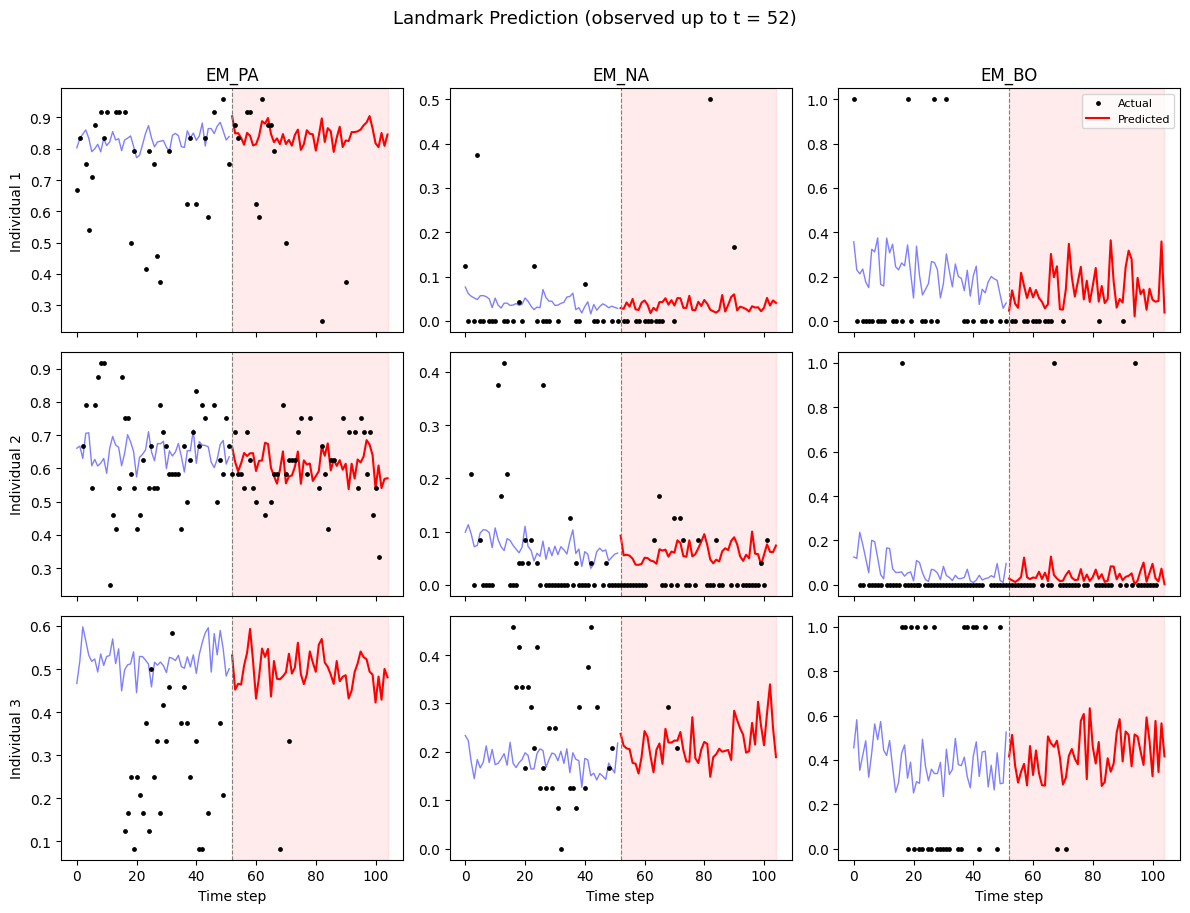

In [8]:
rng = np.random.default_rng(123)
chosen = sorted(rng.choice(len(test_indices), size=3, replace=False))
time_axis = np.arange(seq_len)

n_outcomes = len(outcome_cols)
fig, axes = plt.subplots(3, n_outcomes, figsize=(4 * n_outcomes, 9), sharex=True)

for row, c in enumerate(chosen):
    for col, vname in enumerate(outcome_cols):
        ax = axes[row, col]
        vidx = feature_cols.index(vname)

        actual_vals = all_actual[c, :, vidx]
        pred_vals = all_predicted[c, :, vidx]
        obs_mask_c = test_mask[c, :, vidx].astype(bool)

        # Only plot actual where observed (scatter to avoid joining gaps)
        ax.scatter(time_axis[obs_mask_c], actual_vals[obs_mask_c],
                   c="k", s=6, zorder=3, label="Actual")
        ax.plot(time_axis[:landmark_t], pred_vals[:landmark_t],
                "b-", linewidth=1, alpha=0.5)
        ax.plot(time_axis[landmark_t:], pred_vals[landmark_t:],
                "r-", linewidth=1.5, label="Predicted")

        ax.axvspan(landmark_t, seq_len - 1, alpha=0.08, color="red")
        ax.axvline(landmark_t, color="grey", linestyle="--", linewidth=0.8)

        if row == 0:
            ax.set_title(vname, fontsize=12)
        if col == 0:
            ax.set_ylabel(f"Individual {row + 1}", fontsize=10)
        if row == 2:
            ax.set_xlabel("Time step")

axes[0, -1].legend(loc="upper right", fontsize=8)
fig.suptitle(f"Landmark Prediction (observed up to t = {landmark_t})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. LMM / GLMM benchmark

LMM for continuous/bounded outcomes, logistic GLMM for binary (EM_BO).
Both fitted on **all** time points of training subjects (symmetric with VAE).
BLUPs computed from pre-landmark observations of test subjects only.

In [9]:
train_indices = list(train_ds.indices)
n_test = len(test_indices)

lmm_predictions = np.zeros((n_test, seq_len, n_features))


def _expit(x):
    """Numerically stable sigmoid."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


def _glmm_blup(y_obs, X_obs, Z_obs, beta_hat, D, max_iter=25, tol=1e-6):
    """Compute approximate GLMM BLUPs via penalised IRLS (PQL)."""
    D_inv = np.linalg.solve(D + 1e-8 * np.eye(D.shape[0]), np.eye(D.shape[0]))
    u = np.zeros(D.shape[0])
    for _ in range(max_iter):
        eta = X_obs @ beta_hat + Z_obs @ u
        mu = _expit(eta)
        w = mu * (1.0 - mu) + 1e-8
        score = Z_obs.T @ (y_obs - mu) - D_inv @ u
        H = -(Z_obs.T @ (Z_obs * w[:, None]) + D_inv)
        delta = np.linalg.solve(H, score)
        u = u - delta
        if np.max(np.abs(delta)) < tol:
            break
    return u


for col_idx, vname in enumerate(outcome_cols):
    is_binary = (vname == "EM_BO")
    model_label = "GLMM" if is_binary else "LMM"
    print(f"  Fitting {model_label} for {vname}...", end=" ", flush=True)

    # Build training data from ALL time points of training subjects
    rows = []
    for i in train_indices:
        for t in range(seq_len):
            if mask[i, t, col_idx] == 1.0:
                row = {
                    "subject": int(i), "time": t,
                    "y": float(data[i, t, col_idx]),
                    "sin_hrs": float(data[i, t, feature_cols.index("sin_hrs")]),
                    "cos_hrs": float(data[i, t, feature_cols.index("cos_hrs")]),
                }
                for b, bcol in enumerate(baseline_cols):
                    row[bcol] = float(baseline[i, b])
                rows.append(row)

    df_train = pd.DataFrame(rows)

    fixed_formula = "y ~ time + sin_hrs + cos_hrs + " + " + ".join(baseline_cols)
    re_formula = "1 + time"

    if is_binary:
        # ── GLMM (logistic) for binary outcome ──────────────────────────
        from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
        import scipy.sparse as sparse

        y_train = df_train["y"].values
        X_train = np.column_stack([
            np.ones(len(df_train)),
            df_train["time"].values,
            df_train["sin_hrs"].values,
            df_train["cos_hrs"].values,
        ] + [df_train[bc].values for bc in baseline_cols])

        subjects = df_train["subject"].values
        unique_subjects = np.unique(subjects)
        n_train_subj = len(unique_subjects)
        subj_map = {s: i for i, s in enumerate(unique_subjects)}

        n_rows = len(df_train)
        row_idx, col_idx_sp, vals = [], [], []
        for r in range(n_rows):
            si = subj_map[subjects[r]]
            row_idx.append(r); col_idx_sp.append(si); vals.append(1.0)
            row_idx.append(r); col_idx_sp.append(n_train_subj + si)
            vals.append(float(df_train.iloc[r]["time"]))

        exog_vc = sparse.csc_matrix(
            (vals, (row_idx, col_idx_sp)),
            shape=(n_rows, 2 * n_train_subj),
        )
        ident = np.array([0] * n_train_subj + [1] * n_train_subj)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            glmm = BinomialBayesMixedGLM(y_train, X_train, exog_vc, ident)
            glmm_result = glmm.fit_map()

        beta_hat = glmm_result.fe_mean
        vcp = glmm_result.vcp_mean
        sigma_intercept = np.exp(vcp[0])
        sigma_slope = np.exp(vcp[1])
        D = np.diag([sigma_intercept**2, sigma_slope**2])
        print(f"done (sd_int={sigma_intercept:.4f}, sd_slope={sigma_slope:.4f})")

        for j, subj_idx in enumerate(test_indices):
            obs_times, obs_y, obs_sin, obs_cos = [], [], [], []
            for t in range(landmark_t):
                if mask[subj_idx, t, col_idx] == 1.0:
                    obs_times.append(t)
                    obs_y.append(data[subj_idx, t, col_idx])
                    obs_sin.append(data[subj_idx, t, feature_cols.index("sin_hrs")])
                    obs_cos.append(data[subj_idx, t, feature_cols.index("cos_hrs")])

            bl_vals = [baseline[subj_idx, b] for b in range(n_baseline)]

            if len(obs_times) == 0:
                for t in range(seq_len):
                    sin_t = data[subj_idx, t, feature_cols.index("sin_hrs")]
                    cos_t = data[subj_idx, t, feature_cols.index("cos_hrs")]
                    x_t = np.array([1.0, t, sin_t, cos_t] + bl_vals)
                    lmm_predictions[j, t, col_idx] = _expit(x_t @ beta_hat)
                continue

            obs_times_arr = np.array(obs_times, dtype=float)
            obs_y_arr = np.array(obs_y)
            n_obs = len(obs_times)

            X_obs = np.column_stack([
                np.ones(n_obs), obs_times_arr,
                np.array(obs_sin), np.array(obs_cos),
                np.tile(bl_vals, (n_obs, 1)),
            ])
            Z_obs = np.column_stack([np.ones(n_obs), obs_times_arr])

            u_hat = _glmm_blup(obs_y_arr, X_obs, Z_obs, beta_hat, D)

            for t in range(seq_len):
                sin_t = data[subj_idx, t, feature_cols.index("sin_hrs")]
                cos_t = data[subj_idx, t, feature_cols.index("cos_hrs")]
                x_t = np.array([1.0, t, sin_t, cos_t] + bl_vals)
                z_t = np.array([1.0, t])
                eta = x_t @ beta_hat + z_t @ u_hat
                lmm_predictions[j, t, col_idx] = _expit(eta)

    else:
        # ── LMM for continuous/bounded outcomes ──────────────────────────
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            md = smf.mixedlm(fixed_formula, df_train, groups=df_train["subject"],
                             re_formula=re_formula)
            mdf = md.fit(reml=True, method="lbfgs")

        beta_hat = np.array(mdf.fe_params)
        D = np.array(mdf.cov_re)
        sigma2_e = mdf.scale
        print(f"done (var_e={sigma2_e:.4f})")

        for j, subj_idx in enumerate(test_indices):
            obs_times, obs_y, obs_sin, obs_cos = [], [], [], []
            for t in range(landmark_t):
                if mask[subj_idx, t, col_idx] == 1.0:
                    obs_times.append(t)
                    obs_y.append(data[subj_idx, t, col_idx])
                    obs_sin.append(data[subj_idx, t, feature_cols.index("sin_hrs")])
                    obs_cos.append(data[subj_idx, t, feature_cols.index("cos_hrs")])

            bl_vals = [baseline[subj_idx, b] for b in range(n_baseline)]

            if len(obs_times) == 0:
                for t in range(seq_len):
                    sin_t = data[subj_idx, t, feature_cols.index("sin_hrs")]
                    cos_t = data[subj_idx, t, feature_cols.index("cos_hrs")]
                    x_t = np.array([1.0, t, sin_t, cos_t] + bl_vals)
                    lmm_predictions[j, t, col_idx] = x_t @ beta_hat
                continue

            obs_times_arr = np.array(obs_times, dtype=float)
            obs_y_arr = np.array(obs_y)
            n_obs = len(obs_times)

            X_obs = np.column_stack([
                np.ones(n_obs), obs_times_arr,
                np.array(obs_sin), np.array(obs_cos),
                np.tile(bl_vals, (n_obs, 1)),
            ])
            Z_obs = np.column_stack([np.ones(n_obs), obs_times_arr])

            r = obs_y_arr - X_obs @ beta_hat
            V = Z_obs @ D @ Z_obs.T + sigma2_e * np.eye(n_obs) + 1e-6 * np.eye(n_obs)
            u_hat = D @ Z_obs.T @ np.linalg.solve(V, r)

            for t in range(seq_len):
                sin_t = data[subj_idx, t, feature_cols.index("sin_hrs")]
                cos_t = data[subj_idx, t, feature_cols.index("cos_hrs")]
                x_t = np.array([1.0, t, sin_t, cos_t] + bl_vals)
                z_t = np.array([1.0, t])
                lmm_predictions[j, t, col_idx] = x_t @ beta_hat + z_t @ u_hat

        # Clip bounded predictions to [0, 1]
        lmm_predictions[:, :, col_idx] = np.clip(lmm_predictions[:, :, col_idx], 0, 1)

  Fitting LMM for EM_PA... done (var_e=0.0236)
  Fitting LMM for EM_NA... done (var_e=0.0156)
  Fitting GLMM for EM_BO... done (sd_int=1.1787, sd_slope=1.2401)


## 8. Model comparison (test set)

In [10]:
lmm_future = lmm_predictions[:, landmark_t:, :]

eps_ll = 1e-7

results = []

for col_idx, vname in enumerate(outcome_cols):
    a = future_actual[:, :, col_idx].ravel()
    valid = future_mask[:, :, col_idx].ravel().astype(bool)
    is_binary = (vname == "EM_BO")

    bench_label = "GLMM" if is_binary else "LMM"
    for model_name, preds in [("VAE", future_pred), (bench_label, lmm_future)]:
        p = preds[:, :, col_idx].ravel()
        rmse = np.sqrt(np.mean((a[valid] - p[valid]) ** 2))
        corr = np.corrcoef(a[valid], p[valid])[0, 1] if np.nanstd(a[valid]) > 0 else float("nan")

        row = {"Variable": vname, "Model": model_name,
               "RMSE": rmse, "Corr": corr}

        if is_binary:
            p_clip = np.clip(p[valid], eps_ll, 1 - eps_ll)
            row["LogLik"] = -log_loss(a[valid], p_clip)
            row["AUC"] = roc_auc_score(a[valid], p[valid])
        else:
            sigma = rmse
            row["LogLik"] = (-0.5 * np.mean(((a[valid] - p[valid]) / max(sigma, eps_ll)) ** 2)
                            - np.log(max(sigma, eps_ll)) - 0.5 * np.log(2 * np.pi))

        results.append(row)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="{:.4f}".format))
print(f"\nBest HP: lr={best_hp['learning_rate']:.0e}, weight_decay={best_hp['weight_decay']:.0e}")

Variable Model   RMSE   Corr  LogLik    AUC
   EM_PA   VAE 0.2216 0.4719  0.0881    NaN
   EM_PA   LMM 0.2101 0.6402  0.1412    NaN
   EM_NA   VAE 0.1536 0.5330  0.4548    NaN
   EM_NA   LMM 0.1437 0.6075  0.5211    NaN
   EM_BO   VAE 0.3864 0.5203 -0.4693 0.8150
   EM_BO  GLMM 0.7170 0.2845 -8.2658 0.6408

Best HP: lr=5e-04, weight_decay=1e-04


## 9. Comparison plot

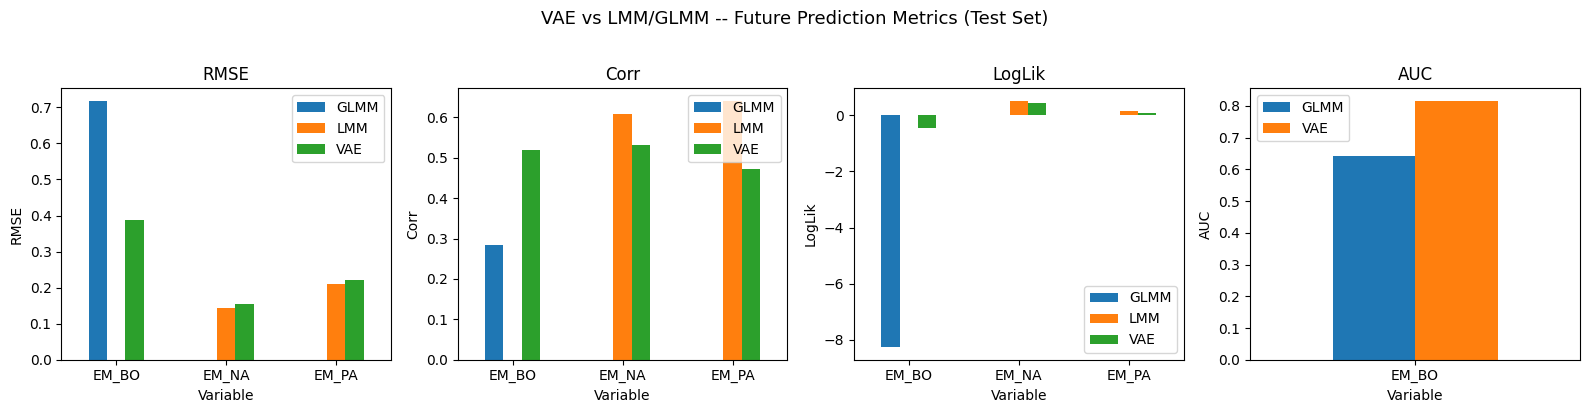

In [11]:
metrics = ["RMSE", "Corr", "LogLik"]
if "AUC" in results_df.columns:
    metrics.append("AUC")

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))

for ax, metric in zip(axes, metrics):
    sub = results_df.dropna(subset=[metric])
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    pivot = sub.pivot(index="Variable", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(title="")

fig.suptitle("VAE vs LMM/GLMM -- Future Prediction Metrics (Test Set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()